# Fit a SurfaceShearJAX to the NCSX plasma surface

Objective: integrated squared facet distance from the free shear surface to a triangulated mesh of the target (`surface_distance.surface_surface_distance`).

Optimizer: L-BFGS-B with box bounds from `SurfaceShearJAX.get_bounds()`. Jacobian via JAX autodiff. History logged every 20 iterations.

In [1]:
import time
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import grad, jit
from scipy.optimize import minimize
from simsopt import load

from quadcoil.surface import SurfaceJAX
from surface_distance import surface_surface_distance
from surface_transport import SurfaceShearJAX, SurfaceBeltramiJAX
from utils import plot_gamma, to_vtk

def plot_gamma(surf, close=True, ax=None, **kwargs):
    """Plot ``surf.gamma()`` of a ``SurfaceJAX`` as a 3D surface, equal aspect."""
    gamma = surf.gamma()
    if close:
        # quadpoints are open grids in [0, 1); wrap once in theta (and in phi
        # only if the phi grid spans the whole torus) so the mesh has no seam.
        gamma = np.concatenate([gamma, gamma[:, :1]], axis=1)
        if np.isclose(float(surf.quadpoints_phi[-1] + surf.dphi), 1.0):
            gamma = np.concatenate([gamma, gamma[:1]], axis=0)

    if ax is None:
        ax = plt.figure(figsize=(7, 6)).add_subplot(projection='3d')
    x, y, z = gamma[..., 0], gamma[..., 1], gamma[..., 2]
    ax.plot_surface(
        x, y, z,
        **{'rstride': 1, 'cstride': 1, 'linewidth': 0,
           'antialiased': False, 'cmap': 'viridis', **kwargs},
    )
    ax.set_aspect('equal')  # matplotlib >= 3.6
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    return ax

In [2]:
# Target: second surface in ncsx.json (plasma-scale NCSX)
_, simsopt_surface = load('ncsx.json')
target_surface = SurfaceJAX.from_simsopt(simsopt_surface)
target_volume = simsopt_surface.volume()
minor_radius_target = np.sqrt(target_volume / (2 * np.pi**2) / simsopt_surface.major_radius())
print('Target surface volume:    ', target_volume)
print('Seed surface minor radius:', minor_radius_target)
# Facet-mesh resolution for the distance objective
n_phi, n_theta = 32, 32

Target surface volume:     2.9787172145367062
Seed surface minor radius: 0.32575916842151176


In [3]:

# Initial shear surface: circular seed from major/minor radius, zero dofs
m_shear = ((4, 4), (2, 2), (4, 4), (2, 2), (2, 2))
init_surface = SurfaceShearJAX(
    nfp=simsopt_surface.nfp,
    stellsym=simsopt_surface.stellsym,
    seed_major_radius=simsopt_surface.major_radius(),
    seed_minor_radius=minor_radius_target,
    quadpoints_phi=jnp.asarray(simsopt_surface.quadpoints_phi),
    quadpoints_theta=jnp.asarray(simsopt_surface.quadpoints_theta),
    m_shear=m_shear,
)



In [4]:

# Initial shear surface: circular seed from major/minor radius, zero dofs
init_surface_b = SurfaceBeltramiJAX(
    nfp=simsopt_surface.nfp,
    stellsym=simsopt_surface.stellsym,
    seed_major_radius=simsopt_surface.major_radius(),
    seed_minor_radius=minor_radius_target,
    quadpoints_phi=jnp.asarray(simsopt_surface.quadpoints_phi),
    quadpoints_theta=jnp.asarray(simsopt_surface.quadpoints_theta),
    step_num=10, # Step number for time evolution
    m_per_period=3,
    min_lam=1e-5,
    max_lam=7,
    n_lam=1000,
    # dofs=None,
    # box_r=None, # By default based on the major and minor radius
    # box_z=None,
    max_order=50,
    max_iter=100,
    tol=1e-5,
    pi_guard=1e-3,
    polish=True,
)

# # Facet-mesh resolution for the distance objective
# n_phi, n_theta = 32, 32

In [5]:
print(init_surface_b.basis.m)
print(init_surface_b.basis.lam)

[0 0 0 0 0 0 3 3 3 3 3 3 6 6 6 9 9]
[3.36438497 3.83780025 4.48192123 5.2340609  6.05408657 6.91789775
 3.89512105 4.58749272 5.33236177 6.07909357 6.67949033 6.81862113
 4.56225302 5.41464913 6.26015816 5.33311174 6.32199116]


In [8]:
def make_surface(dofs):
    """Copy of init_surface with the given dofs."""
    return SurfaceShearJAX(
        nfp=init_surface.nfp,
        stellsym=init_surface.stellsym,
        seed_major_radius=init_surface.seed_major_radius,
        seed_minor_radius=init_surface.seed_minor_radius,
        quadpoints_phi=init_surface.quadpoints_phi,
        quadpoints_theta=init_surface.quadpoints_theta,
        m_shear=init_surface.m_shear,
        dofs=dofs,
        z_max=init_surface.z_max,
        r_max=init_surface.r_max,
    )

def make_surface_b(dofs):
    """Copy of init_surface with the given dofs."""
    return SurfaceBeltramiJAX(
        nfp=init_surface_b.nfp,
        stellsym=init_surface_b.stellsym,
        seed_major_radius=init_surface_b.seed_major_radius,
        seed_minor_radius=init_surface_b.seed_minor_radius,
        quadpoints_phi=init_surface_b.quadpoints_phi,
        quadpoints_theta=init_surface_b.quadpoints_theta,
        step_num=init_surface_b.step_num,
        m_per_period=init_surface_b.m_per_period,
        min_lam=init_surface_b.min_lam,
        max_lam=init_surface_b.max_lam,
        n_lam=init_surface_b.n_lam,
        dofs=dofs,
        box_r=init_surface_b.box_r,
        box_z=init_surface_b.box_z,
        max_order=init_surface_b.max_order,
        max_iter=init_surface_b.max_iter,
        tol=init_surface_b.tol,
        pi_guard=init_surface_b.pi_guard,
        polish=init_surface_b.polish,
    )

@jit
def f(dofs):
    temp_surface = make_surface(dofs)
    return surface_surface_distance(
        target_surface, temp_surface, n_phi, n_theta
    )

@jit
def f_b(dofs):
    temp_surface = make_surface_b(dofs)
    return surface_surface_distance(
        target_surface, temp_surface, n_phi, n_theta
    )


df = jit(grad(f))
df_b = jit(grad(f_b))


def f_np(x):
    return float(f(jnp.asarray(x)))
    
def f_b_np(x):
    return float(f_b(jnp.asarray(x)))


def jac_np(x):
    return np.asarray(df(jnp.asarray(x)), dtype=float)
    
def jac_b_np(x):
    return np.asarray(df_b(jnp.asarray(x)), dtype=float)

In [11]:
dofs_test = np.zeros(len(init_surface_b.basis.m))
dofs_test[6] = 0.1
dofs_test[7] = 0.2

<Axes3D: xlabel='x', ylabel='y', zlabel='z'>

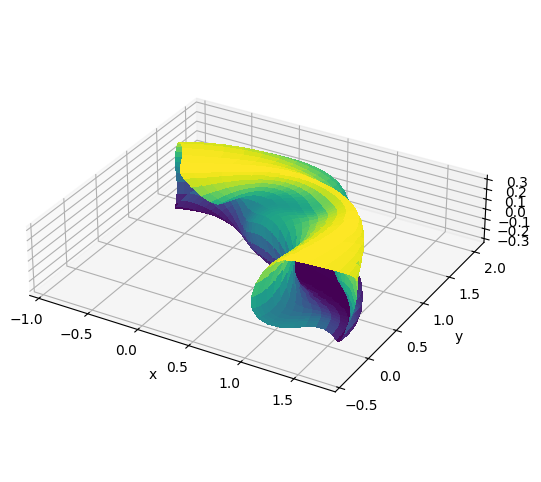

In [12]:
surf_test = make_surface_b(dofs_test)
# to_vtk(surf_test, 'test_beltrami_surface')

plot_gamma(surf_test)

In [13]:
# History buffers (filled every 20 L-BFGS-B iterations)
n_iter_history, dofs_history, f_history, time_history = [], [], [], []
state = {'n_iter': 0}


def callback(xk):
    state['n_iter'] += 1
    if state['n_iter'] % 20 == 0:
        n_iter_history.append(state['n_iter'])
        dofs_history.append(np.asarray(xk).copy())
        f_history.append(f_np(xk))
        time_history.append(time.time())


lb, ub = init_surface.get_bounds()
bounds = list(zip(np.asarray(lb), np.asarray(ub)))

result = minimize(
    f_np,
    x0=np.asarray(init_surface.dofs, dtype=float),
    jac=jac_np,
    method='L-BFGS-B',  # box-constrained
    bounds=bounds,
    callback=callback,
)

print(result.message)
print('nit =', result.nit, '  fun =', result.fun)
print('logged iterations:', n_iter_history)


KeyboardInterrupt



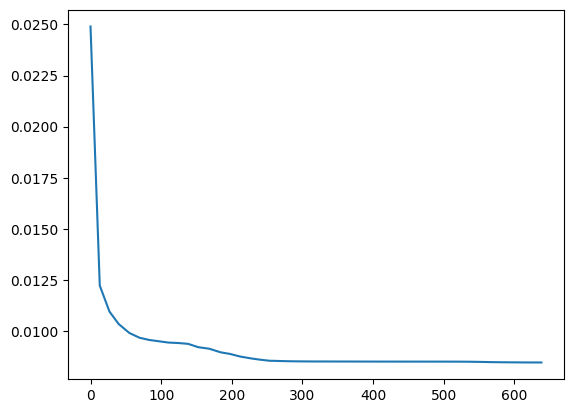

In [9]:
plt.plot(np.array(time_history)-time_history[0], f_history)

In [10]:
final_surface = make_surface(result.x)

In [11]:
to_vtk(final_surface, 'final_surface')
to_vtk(target_surface, 'target_surface')

'/scratch/Projects-scratch/surface-parameterization/target_surface.vts'

In [12]:
target_surface.dofs.shape

(187,)

In [ ]:
# History buffers (filled every 20 L-BFGS-B iterations)
n_iter_b_history, dofs_b_history, f_b_history, time_b_history = [], [], [], []
state = {'n_iter': 0}


def callback_b(xk):
    state['n_iter'] += 1
    if state['n_iter'] % 20 == 0:
        print('f', f_b_np(xk))
        n_iter_history.append(state['n_iter'])
        dofs_history.append(np.asarray(xk).copy())
        f_history.append(f_b_np(xk))
        time_history.append(time.time())


# lb, ub = init_surface_b.get_bounds()
# bounds = list(zip(np.asarray(lb), np.asarray(ub)))

result = minimize(
    f_b_np,
    x0=np.asarray(init_surface_b.dofs, dtype=float),
    jac=jac_b_np,
    method='L-BFGS-B',  # box-constrained
    # bounds=bounds,
    callback=callback,
)

print(result.message)
print('nit =', result.nit, '  fun =', result.fun)
print('logged iterations:', n_iter_history)

In [ ]:
plt.plot(np.array(time_b_history)-time_b_history[0], f_history)